### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp


varianza= 0.9340115712732936


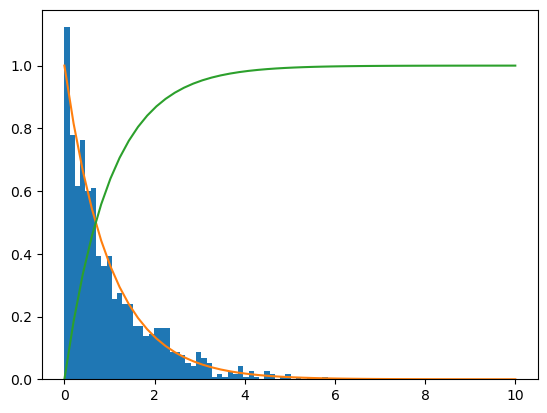

In [2]:


valori = sp.stats.gamma(1)

valori_sample = valori.rvs(size=1000)


x=np.linspace(0,10)
fit = sp.stats.gamma.fit(valori_sample)


plt.hist(valori_sample,density=True,bins=50)
plt.plot(x,valori.pdf(x))
plt.plot(x,valori.cdf(x))

print("varianza=",np.var(valori_sample))




### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

In [3]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt



1.0458509739490227 | 1.0362081563168128e-15 | 3.185078648162252 | 2.2408081316408848e-09


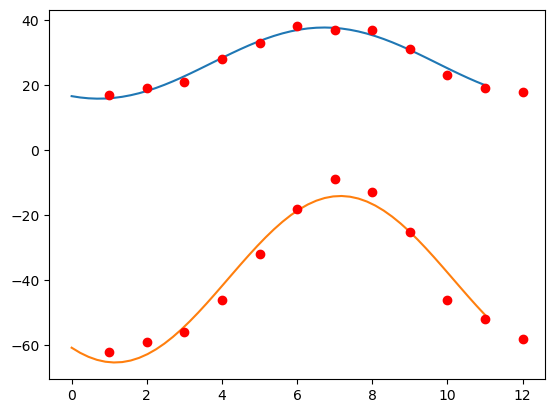

In [7]:


months = np.arange(1,13)

def funzione(x, a,b,c,d):
    return a*x**3 + b*x**2 + c*x + d


def sin(x,a,b,c):
    return c + a*np.sin((x+b)*2*np.pi/12)


params_max, _ = sp.optimize.curve_fit(sin,months,temp_max)

params_min, _ = sp.optimize.curve_fit(sin,months,temp_min)


y_pred_max = sin(months,*params_max)
y_pred_min = sin(months,*params_min)


x=np.linspace(0,11)

plt.plot(x,sin(x,*params_max))
plt.plot(months,temp_max,"ro")

plt.plot(x,sin(x,*params_min))
plt.plot(months,temp_min,"ro")

#calcolo di RMSE e MAE

mae1 = np.mean(np.abs(temp_max - y_pred_max))
rmse1 = np.sqrt(np.mean(temp_max - y_pred_max)**2)

mae2 = np.mean(np.abs(temp_min - y_pred_min))
rmse2 = np.sqrt(np.mean(temp_min - y_pred_min)**2)

print(mae1,"|",rmse1,"|",mae2,"|",rmse2)

### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

In [ ]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df



model    Toyota Corolla
mpg                33.9
cyl                   4
disp               71.1
hp                   65
drat               4.22
wt                1.835
qsec               19.9
vs                    1
am                    1
gear                  4
carb                  1
Name: 19, dtype: object

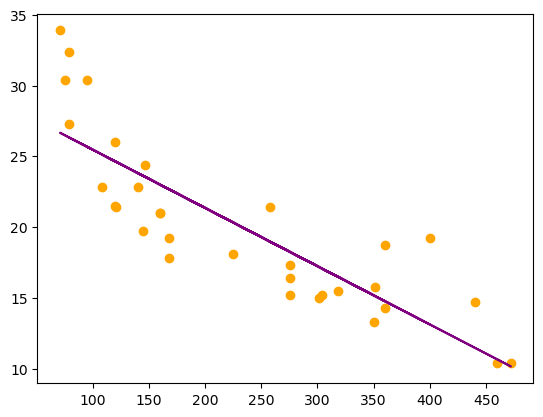

In [50]:

x = df["disp"]

y = df["mpg"]

params = np.polyfit(x,y,1)

y_p = np.polyval(params,x)

plt.scatter(x,y,color="orange")
plt.plot(x,y_p,color="purple")